# Real vs synthetic IMU comparison

This notebook organizes two complementary analyses for the same exported capture:

1. time-domain comparison between real and virtual IMU;
2. distribution comparison in the frequency domain using FFT + t-SNE.

The frequency-domain pipeline logic was moved to `evaluation/tsne.py`, keeping the notebook focused on configuration and visualization.

In [213]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "pose_module").exists() and (candidate / "output").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not find the project root. Open the notebook inside the IMUGPT repository.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.tsne import run_frequency_domain_tsne, run_frequency_domain_tsne_all_captures
from evaluation.utils import build_exported_capture_table, plot_real_virtual_capture

plt.style.use("seaborn-v0_8-whitegrid")

## Data loading

Select here the capture that will be used both for the time-domain plot and for the FFT + t-SNE pipeline.

In [214]:
OUTPUT_ROOT = PROJECT_ROOT / "output" / "robot_emotions_virtual_imu_v2_all_dataset"
CAPTURES_DF = build_exported_capture_table(OUTPUT_ROOT)

DOMAIN = "10ms"
USER_ID = 2
TAG_NUMBER = 1
TAKE_ID = None

display(CAPTURES_DF.head())

,clip_id,domain,user_id,tag_number,take_id,clip_dir,pose_dir,emotion,modality,stimulus,stimulus_details,protocol_tag_10ms,protocol_tag_30ms
0,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,/home/henriquesouza/IMUGPT/output/robot_emotio...,/home/henriquesouza/IMUGPT/output/robot_emotio...,Neutrality,Standing,None,None,1.0,1
1,robot_emotions_10ms_u02_tag05,10ms,2,5,NaN,/home/henriquesouza/IMUGPT/output/robot_emotio...,/home/henriquesouza/IMUGPT/output/robot_emotio...,Sadness,Sitting,Visual methods,Show/have the participant choose sad video clips,5.0,7
2,robot_emotions_10ms_u02_tag06,10ms,2,6,NaN,/home/henriquesouza/IMUGPT/output/robot_emotio...,/home/henriquesouza/IMUGPT/output/robot_emotio...,Sadness,Sitting,Autobiographical recall,Ask the participant to remember a sad episode,6.0,8
3,robot_emotions_10ms_u02_tag07,10ms,2,7,NaN,/home/henriquesouza/IMUGPT/output/robot_emotio...,/home/henriquesouza/IMUGPT/output/robot_emotio...,Sadness,Standing,Autobiographical recall,Ask the participant to remember a sad episode,7.0,17
4,robot_emotions_10ms_u02_tag09,10ms,2,9,NaN,/home/henriquesouza/IMUGPT/output/robot_emotio...,/home/henriquesouza/IMUGPT/output/robot_emotio...,Happiness,Sitting,Visual methods,Show/have the participant choose happy video c...,9.0,5


## Time-domain comparison

The block below keeps using the project's existing helper for visual inspection in the time domain.

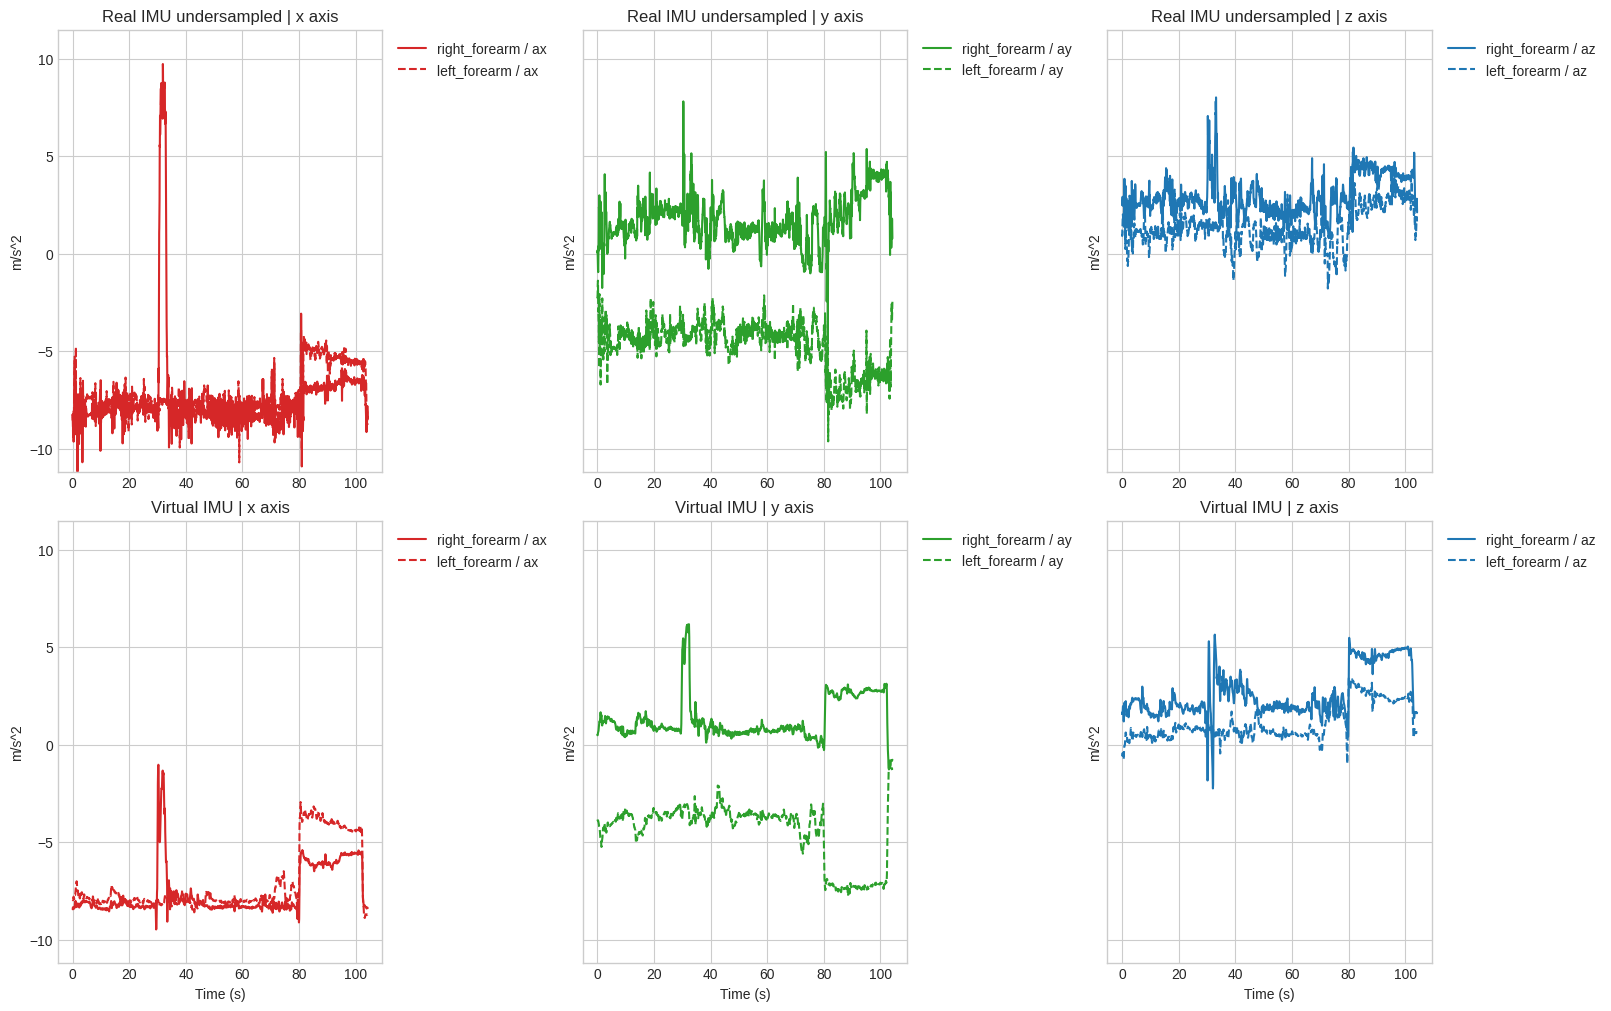

,clip_id,domain,user_id,tag_number,take_id,emotion,modality,stimulus,stimulus_details,protocol_tag_10ms,protocol_tag_30ms,signal_group,undersampled_real_to_virtual,selected_sensors,real_frames,real_plot_frames,virtual_frames,real_original_frequency_hz,real_plot_frequency_hz,virtual_frequency_hz,real_vs_virtual_mean_time_error_ms,real_vs_virtual_max_time_error_ms,frame_aligned_available,frame_aligned_frames
0,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,None,None,1,1,acc,True,"right_forearm, left_forearm",11590,2086,2086,111.113278,29.966164,29.966164,2.933503,245.96405,False,None


In [215]:
SIGNAL_GROUP = "acc"  # "acc" or "gyro"
SENSOR_NAMES = ["right_forearm", "left_forearm"]  # None for all shared sensors
TIME_RANGE_SEC = None
FIGSIZE = (16, 10)
LINE_WIDTH = 1.5
UNDERSAMPLE_REAL_TO_VIRTUAL = True

summary_df, fig = plot_real_virtual_capture(
    CAPTURES_DF,
    domain=DOMAIN,
    user_id=USER_ID,
    tag_number=TAG_NUMBER,
    take_id=TAKE_ID,
    signal_group=SIGNAL_GROUP,
    sensor_names=SENSOR_NAMES,
    time_range_sec=TIME_RANGE_SEC,
    figsize=FIGSIZE,
    line_width=LINE_WIDTH,
    undersample_real_to_virtual=UNDERSAMPLE_REAL_TO_VIRTUAL,
    show=True,
)

display(summary_df)

## FFT + t-SNE in the frequency domain

The pipeline below performs:

- sensor and signal-group selection;
- resampling of the real signal to the synthetic rate;
- window segmentation with optional overlap;
- FFT using only positive frequencies;
- `log(1 + magnitude)` and per-window normalization;
- combined dataset assembly and 2D projection with t-SNE.

In [216]:
TSNE_SIGNAL_GROUPS = ("acc",)  # ("acc",), ("gyro",), or ("acc", "gyro")
TSNE_SELECTED_SENSORS = None
TSNE_SELECTED_AXES = ("x", "y", "z")

WINDOW_TYPE = "n_samples"  # "n_samples" or "seconds"

WINDOW_SIZE = 4 # used when WINDOW_TYPE == "n_samples"
WINDOW_DURATION_SEC = 1.0  # used when WINDOW_TYPE == "seconds"

STRIDE_OR_OVERLAP = "overlap"  # "stride" or "overlap"
STRIDE_SAMPLES = 10  # used when STRIDE_OR_OVERLAP == "stride" and WINDOW_TYPE == "n_samples"
STRIDE_SEC = 0.2  # used when STRIDE_OR_OVERLAP == "stride" and WINDOW_TYPE == "seconds"
OVERLAP = 0.7  # ratio in [0, 1); used when STRIDE_OR_OVERLAP == "overlap"

RESAMPLE_METHOD = "resample_poly" # "resample_poly" or "resample"
NORMALIZATION = "zscore" # "zscore" or "energy"
PERPLEXITY = 30
TSNE_RANDOM_STATE = 42
USE_LOG_POWER = True
DROP_DC = True

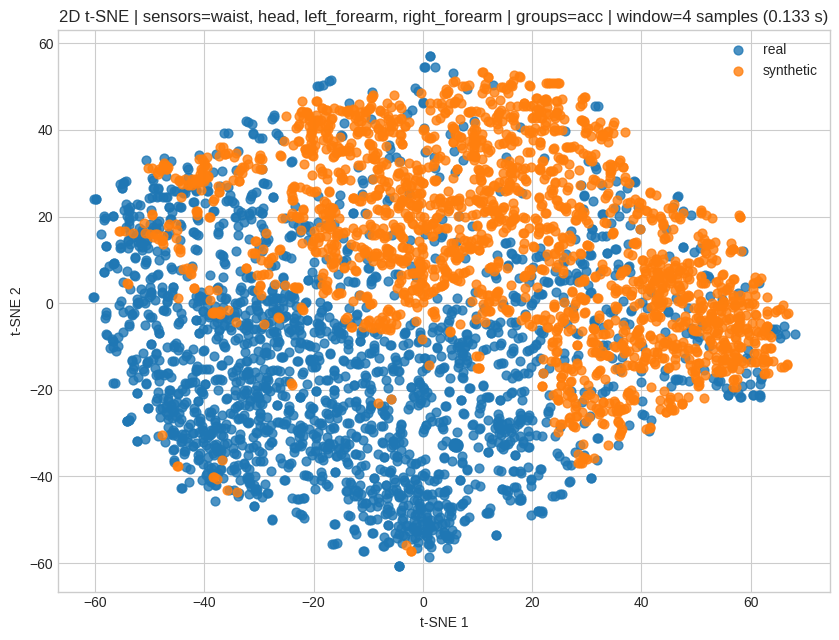

,domain,num_frames,num_sensors,num_channels_per_sensor,sampling_frequency_hz,selected_sensors,selected_axes,signal_groups
0,real,11590,4,3,111.113278,"waist, head, left_forearm, right_forearm","x, y, z",acc
1,synthetic,2086,4,3,29.966164,"waist, head, left_forearm, right_forearm","x, y, z",acc


,aligned_frames,aligned_sampling_frequency_hz,real_frequency_hz_before,synthetic_frequency_hz,overlap_start_sec,overlap_end_sec,overlap_duration_sec,resample_method
0,2086,29.966164,111.113278,29.966164,0.0,104.237465,104.237465,"resample_poly(up=113, down=419)"


,window_type,window_size_samples,window_duration_sec,step_mode,step_size_samples,step_duration_sec,overlap_ratio,overlap,real_num_windows,synthetic_num_windows,feature_dim
0,n_samples,4,0.133484,overlap,1,0.033371,0.7,0.7,2083,2083,24


,tsne_1,tsne_2,label,domain,window_size
0,-54.172489,-27.300875,0,real,4
1,-16.442657,-28.597145,0,real,4
2,-31.695969,-1.545388,0,real,4
3,-32.104851,-4.582598,0,real,4
4,-28.661823,-11.978683,0,real,4


In [217]:
tsne_result = run_frequency_domain_tsne(
    CAPTURES_DF,
    domain=DOMAIN,
    user_id=USER_ID,
    tag_number=TAG_NUMBER,
    take_id=TAKE_ID,
    signal_groups=TSNE_SIGNAL_GROUPS,
    selected_sensors=TSNE_SELECTED_SENSORS,
    selected_axes=TSNE_SELECTED_AXES,
    resample_method=RESAMPLE_METHOD,
    window_type=WINDOW_TYPE,
    window_size=(WINDOW_SIZE if WINDOW_TYPE == "n_samples" else None),
    window_duration_sec=(WINDOW_DURATION_SEC if WINDOW_TYPE == "seconds" else None),
    stride_or_overlap_mode=STRIDE_OR_OVERLAP,
    stride=(STRIDE_SAMPLES if STRIDE_OR_OVERLAP == "stride" and WINDOW_TYPE == "n_samples" else None),
    stride_sec=(STRIDE_SEC if STRIDE_OR_OVERLAP == "stride" and WINDOW_TYPE == "seconds" else None),
    overlap=(OVERLAP if STRIDE_OR_OVERLAP == "overlap" else 0.5),
    normalization=NORMALIZATION,
    perplexity=PERPLEXITY,
    random_state=TSNE_RANDOM_STATE,
    use_log_power=USE_LOG_POWER,
    drop_dc=DROP_DC,
    show=True
)

display(tsne_result["selected_summary_df"])
display(tsne_result["alignment_summary_df"])
display(tsne_result["window_summary_df"])
display(tsne_result["embedding_df"].head())

## Aggregated FFT + t-SNE across all captures

The block below reuses the same frequency-domain pipeline for every exported capture, samples a configurable number of windows per capture/domain, and fits a single t-SNE to visualize real vs synthetic in one plot.

In [218]:
TSNE_ALL_CAPTURE_DOMAINS = None  # e.g. [DOMAIN] to restrict to a single protocol domain
TSNE_ALL_CAPTURE_USERS = None  # e.g. [USER_ID]
TSNE_ALL_CAPTURE_TAGS = None  # e.g. [TAG_NUMBER]
TSNE_ALL_CAPTURE_BLACKLIST = [
    ("30ms", 2, 3),
    ("30ms", 2, 5),
    ("30ms", 2, 6),
    ("30ms", 2, 8),
    ("30ms", 4, 1),
    ("30ms", 5, 8),
    ("30ms", 6, 2),
    ("30ms", 6, 3),
    ("30ms", 6, 7),
]  # (domain, user_id, tag_number)
TSNE_ALL_MAX_WINDOWS_PER_CAPTURE_PER_DOMAIN = 24
TSNE_ALL_SKIP_INVALID_CAPTURES = True

,domain,num_captures
0,10ms,36
1,30ms,43


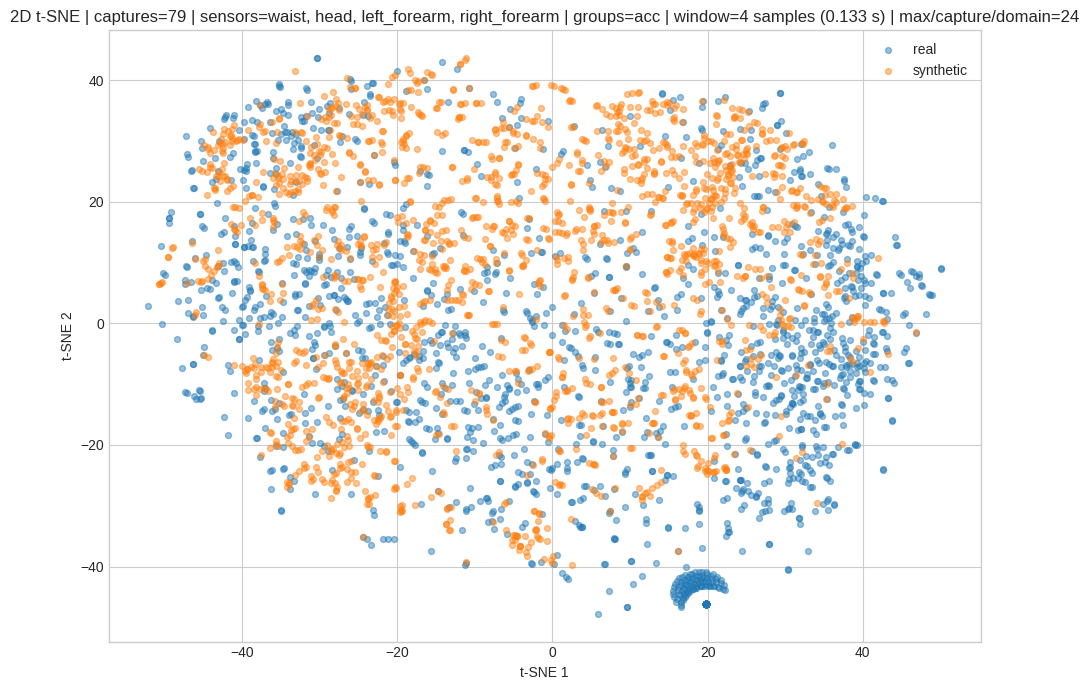

,input_num_captures,processed_num_captures,failed_num_captures,num_points_total,num_real_points,num_synthetic_points,max_windows_per_capture_per_domain,window_size_samples,window_duration_sec,feature_dim
0,79,79,0,3792,1896,1896,24,4,0.133484,24


,capture_index,capture_domain,user_id,tag_number,take_id,clip_id,aligned_sampling_frequency_hz,window_size_samples,window_duration_sec,real_num_windows_total,synthetic_num_windows_total,sampled_real_num_windows,sampled_synthetic_num_windows,feature_dim
0,0,10ms,2,1,NaN,robot_emotions_10ms_u02_tag01,29.966164,4,0.133484,2083,2083,24,24,24
1,1,10ms,2,5,NaN,robot_emotions_10ms_u02_tag05,29.966164,4,0.133484,2085,2085,24,24,24
2,2,10ms,2,6,NaN,robot_emotions_10ms_u02_tag06,29.966164,4,0.133484,2162,2162,24,24,24
3,3,10ms,2,7,NaN,robot_emotions_10ms_u02_tag07,29.966164,4,0.133484,1935,1935,24,24,24
4,4,10ms,2,9,NaN,robot_emotions_10ms_u02_tag09,29.966164,4,0.133484,2047,2047,24,24,24


,tsne_1,tsne_2,label,domain,window_size,capture_index,capture_domain,user_id,tag_number,take_id,clip_id,sample_index_within_capture,sampled_domain
0,46.093296,5.908347,0,real,4,0,10ms,2,1,None,robot_emotions_10ms_u02_tag01,177,real
1,-22.967794,-31.581789,0,real,4,0,10ms,2,1,None,robot_emotions_10ms_u02_tag01,183,real
2,-11.287905,-39.680622,0,real,4,0,10ms,2,1,None,robot_emotions_10ms_u02_tag01,194,real
3,-5.737309,-18.891794,0,real,4,0,10ms,2,1,None,robot_emotions_10ms_u02_tag01,266,real
4,6.988451,10.615455,0,real,4,0,10ms,2,1,None,robot_emotions_10ms_u02_tag01,380,real


In [219]:
tsne_all_captures_df = CAPTURES_DF.copy()

if TSNE_ALL_CAPTURE_DOMAINS is not None:
    tsne_all_captures_df = tsne_all_captures_df[tsne_all_captures_df["domain"].isin(TSNE_ALL_CAPTURE_DOMAINS)].copy()
if TSNE_ALL_CAPTURE_USERS is not None:
    tsne_all_captures_df = tsne_all_captures_df[tsne_all_captures_df["user_id"].isin(TSNE_ALL_CAPTURE_USERS)].copy()
if TSNE_ALL_CAPTURE_TAGS is not None:
    tsne_all_captures_df = tsne_all_captures_df[tsne_all_captures_df["tag_number"].isin(TSNE_ALL_CAPTURE_TAGS)].copy()
if TSNE_ALL_CAPTURE_BLACKLIST:
    tsne_all_capture_blacklist = {
        (str(domain), int(user_id), int(tag_number))
        for domain, user_id, tag_number in TSNE_ALL_CAPTURE_BLACKLIST
    }
    tsne_all_capture_keys = list(
        zip(
            tsne_all_captures_df["domain"].astype(str),
            tsne_all_captures_df["user_id"].astype(int),
            tsne_all_captures_df["tag_number"].astype(int),
        )
    )
    tsne_all_captures_df = tsne_all_captures_df[[capture_key not in tsne_all_capture_blacklist for capture_key in tsne_all_capture_keys]].copy()

display(
    tsne_all_captures_df.groupby("domain")
    .size()
    .rename("num_captures")
    .reset_index()
)

tsne_all_result = run_frequency_domain_tsne_all_captures(
    tsne_all_captures_df,
    signal_groups=TSNE_SIGNAL_GROUPS,
    selected_sensors=TSNE_SELECTED_SENSORS,
    selected_axes=TSNE_SELECTED_AXES,
    resample_method=RESAMPLE_METHOD,
    window_type=WINDOW_TYPE,
    window_size=(WINDOW_SIZE if WINDOW_TYPE == "n_samples" else None),
    window_duration_sec=(WINDOW_DURATION_SEC if WINDOW_TYPE == "seconds" else None),
    stride_or_overlap_mode=STRIDE_OR_OVERLAP,
    stride=(STRIDE_SAMPLES if STRIDE_OR_OVERLAP == "stride" and WINDOW_TYPE == "n_samples" else None),
    stride_sec=(STRIDE_SEC if STRIDE_OR_OVERLAP == "stride" and WINDOW_TYPE == "seconds" else None),
    overlap=(OVERLAP if STRIDE_OR_OVERLAP == "overlap" else 0.5),
    normalization=NORMALIZATION,
    perplexity=PERPLEXITY,
    random_state=TSNE_RANDOM_STATE,
    use_log_power=USE_LOG_POWER,
    drop_dc=DROP_DC,
    max_windows_per_capture_per_domain=TSNE_ALL_MAX_WINDOWS_PER_CAPTURE_PER_DOMAIN,
    skip_invalid_captures=TSNE_ALL_SKIP_INVALID_CAPTURES,
    show=True
)

display(tsne_all_result["aggregate_summary_df"])
display(tsne_all_result["capture_summary_df"].head())
if not tsne_all_result["failed_capture_df"].empty:
    display(tsne_all_result["failed_capture_df"])
display(tsne_all_result["embedding_df"].head())